In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import json
import os
from pathlib import Path
import pandas as pd

In [63]:
BASE_PATH = Path('/content/drive/My Drive/Plant Disease')
TRAIN_PATH = BASE_PATH / 'train'
VAL_PATH = BASE_PATH / 'val'
PARSING_CSV_PATH = BASE_PATH / 'plant_diseases.csv'
REQUIRED_PARSING_COLUMNS = [
    "row_id",
    "folder_name",
    "plant_name",
    "disease_name",
]
PREPARED_DIR = BASE_PATH / "prepared"

In [64]:
class PlantDiseaseParser:
    def __init__(self, csv_path, required_columns):
        self.csv_path = csv_path
        self.required_columns = required_columns
        self.parsing_df = None
        self.parsing_lookup = None
        self.expected_disease_count = None

    def load(self):
        parsing_df = pd.read_csv(self.csv_path)

        missing_columns = [
            column for column in self.required_columns
            if column not in parsing_df.columns
        ]
        if missing_columns:
            raise ValueError(
                "plant_diseases.csv is missing required columns: "
                + ", ".join(missing_columns)
            )

        for column in ["folder_name", "plant_name", "disease_name"]:
            parsing_df[column] = parsing_df[column].astype(str).str.strip()

        self.parsing_df = parsing_df
        return self.parsing_df

    def build_review(self, train_folder_names):
        if self.parsing_df is None:
            self.load()

        review_df = pd.DataFrame({"folder_name": train_folder_names})
        review_df = review_df.merge(
            self.parsing_df[["folder_name", "plant_name", "disease_name"]],
            on="folder_name",
            how="left",
        )
        review_df.insert(0, "row_id", range(1, len(review_df) + 1))
        return review_df.fillna("")

    def validate(self, train_folder_names, val_folder_names, review_df=None):
        if self.parsing_df is None:
            self.load()

        if review_df is None:
            review_df = self.build_review(train_folder_names)

        dataset_folders = set(train_folder_names + val_folder_names)
        csv_folders = set(self.parsing_df["folder_name"])

        missing_in_csv = sorted(dataset_folders - csv_folders)
        if missing_in_csv:
            raise ValueError(
                "Folders missing from plant_diseases.csv:\n- "
                + "\n- ".join(missing_in_csv)
            )

        extra_in_csv = sorted(csv_folders - dataset_folders)
        if extra_in_csv:
            raise ValueError(
                "Rows in plant_diseases.csv that do not exist in the dataset:\n- "
                + "\n- ".join(extra_in_csv)
            )

        blank_mapping_rows = review_df[
            (review_df["plant_name"] == "")
            | (review_df["disease_name"] == "")
        ]
        if not blank_mapping_rows.empty:
            raise ValueError(
                "Folders with blank plant/disease parsing values:\n- "
                + "\n- ".join(blank_mapping_rows["folder_name"].tolist())
            )

        return review_df

    def build_lookup(self):
        if self.parsing_df is None:
            self.load()

        self.parsing_lookup = (
            self.parsing_df
            .set_index("folder_name")[["plant_name", "disease_name"]]
            .to_dict(orient="index")
        )
        return self.parsing_lookup

    def get_expected_disease_count(self):
        if self.parsing_df is None:
            self.load()

        self.expected_disease_count = len(
            {label for label in self.parsing_df["disease_name"] if label}
        )
        return self.expected_disease_count


In [65]:
class DatasetCreator:
    def __init__(self, train_path, val_path, prepared_dir, parser):
        self.train_path = train_path
        self.val_path = val_path
        self.prepared_dir = prepared_dir
        self.parser = parser

    def list_data_folders(self, split_path):
        return sorted([folder.name for folder in split_path.iterdir() if folder.is_dir()])

    def count_images(self, dir_path):
        folder_counts = []

        for folder in sorted(dir_path.iterdir()):
            if folder.is_dir():
                img_count = sum(1 for file in folder.iterdir() if file.is_file())
                folder_counts.append({"folder": folder.name, "count": img_count})

        counts_df = pd.DataFrame(folder_counts)
        counts_df = counts_df.sort_values("count", ascending=False).reset_index(drop=True)
        return counts_df

    def scan_split(self, split_path, split_name, parsing_lookup):
        rows = []

        for class_dir in sorted(split_path.iterdir()):
            if not class_dir.is_dir():
                continue

            raw_label = class_dir.name
            if raw_label not in parsing_lookup:
                raise KeyError(f"Missing parsing rule for folder: {raw_label}")

            plant = parsing_lookup[raw_label]["plant_name"]
            disease_label = parsing_lookup[raw_label]["disease_name"]

            for image_path in sorted(class_dir.iterdir()):
                if not image_path.is_file():
                    continue

                rows.append(
                    {
                        "split": split_name,
                        "raw_label": raw_label,
                        "plant": plant,
                        "disease_label": disease_label,
                        "filename": image_path.name,
                        "filepath": str(image_path.resolve()),
                        "relative_filepath": image_path.relative_to(BASE_PATH).as_posix(),
                    }
                )

        return pd.DataFrame(rows)

    def build_label_maps(self, all_metadata):
        disease_labels = sorted(all_metadata["disease_label"].unique())
        class_to_id = {label: idx for idx, label in enumerate(disease_labels)}
        id_to_class = {idx: label for label, idx in class_to_id.items()}
        return class_to_id, id_to_class



    def save_prepared_outputs(
        self,
        metadata_train,
        metadata_val,
        metadata_all,
        class_to_id,
        id_to_class,
    ):
        self.prepared_dir.mkdir(exist_ok=True)

        metadata_train.to_csv(self.prepared_dir / "metadata_train.csv", index=False)
        metadata_val.to_csv(self.prepared_dir / "metadata_val.csv", index=False)
        metadata_all.to_csv(self.prepared_dir / "metadata_all.csv", index=False)

        with open(self.prepared_dir / "label_map.json", "w", encoding="utf-8") as file:
            json.dump(
                {
                    "class_to_id": class_to_id,
                    "id_to_class": {str(idx): label for idx, label in id_to_class.items()},
                },
                file,
                indent=2,
                ensure_ascii=False,
            )

        summary_lines = [
            f"train_images: {len(metadata_train)}",
            f"val_images: {len(metadata_val)}",
            f"total_images: {len(metadata_all)}",
            f"raw_train_labels: {metadata_train['raw_label'].nunique()}",
            f"raw_val_labels: {metadata_val['raw_label'].nunique()}",
            f"disease_classes: {metadata_all['disease_label'].nunique()}",
            f"plant: {metadata_all['plant'].nunique()}",
            "",
            "top_disease_counts_train:",
        ]

        summary_lines.extend(
            [
                f"- {label}: {count}"
                for label, count in metadata_train["disease_label"].value_counts().head(10).items()
            ]
        )

        (self.prepared_dir / "data_summary.txt").write_text(
            "\n".join(summary_lines),
            encoding="utf-8",
        )

    def create_metadata(self):
        train_folder_names = self.list_data_folders(self.train_path)
        val_folder_names = self.list_data_folders(self.val_path)

        review_df = self.parser.build_review(train_folder_names)
        review_df = self.parser.validate(train_folder_names, val_folder_names, review_df)
        parsing_lookup = self.parser.build_lookup()
        expected_disease_classes = self.parser.get_expected_disease_count()

        train_counts = self.count_images(self.train_path)
        val_counts = self.count_images(self.val_path)
        expected_train_images = train_counts["count"].sum()
        expected_val_images = val_counts["count"].sum()

        metadata_train = self.scan_split(self.train_path, "train", parsing_lookup)
        metadata_val = self.scan_split(self.val_path, "val", parsing_lookup)
        metadata_all = pd.concat([metadata_train, metadata_val], ignore_index=True)

        class_to_id, id_to_class = self.build_label_maps(metadata_all)
        metadata_train["class_id"] = metadata_train["disease_label"].map(class_to_id)
        metadata_val["class_id"] = metadata_val["disease_label"].map(class_to_id)
        metadata_all["class_id"] = metadata_all["disease_label"].map(class_to_id)


        return {
            "train_folder_names": train_folder_names,
            "val_folder_names": val_folder_names,
            "review_df": review_df,
            "train_counts": train_counts,
            "val_counts": val_counts,
            "expected_train_images": expected_train_images,
            "expected_val_images": expected_val_images,
            "expected_disease_classes": expected_disease_classes,
            "metadata_train": metadata_train,
            "metadata_val": metadata_val,
            "metadata_all": metadata_all,
            "class_to_id": class_to_id,
            "id_to_class": id_to_class,
        }

    def save(self, dataset_parts):
        self.save_prepared_outputs(
            dataset_parts["metadata_train"],
            dataset_parts["metadata_val"],
            dataset_parts["metadata_all"],
            dataset_parts["class_to_id"],
            dataset_parts["id_to_class"],
        )


In [66]:
print("Project files:")
print(sorted(os.listdir(BASE_PATH)))

Project files:
['plant_diseases.csv', 'prepared', 'train', 'val']


In [67]:
parser = PlantDiseaseParser(PARSING_CSV_PATH, REQUIRED_PARSING_COLUMNS)
dataset_creator = DatasetCreator(TRAIN_PATH, VAL_PATH, PREPARED_DIR, parser)
dataset_parts = dataset_creator.create_metadata()

In [68]:
print(f"Found {len(dataset_parts['train_folder_names'])} training folders.")
print(f"Found {len(dataset_parts['val_folder_names'])} validation folders.")

Found 82 training folders.
Found 71 validation folders.


In [69]:
print("Train folder names for manual parsing review:")
print("\n".join(f"{row.row_id}. {row.folder_name}" for row in dataset_parts["review_df"].itertuples(index=False)))

Train folder names for manual parsing review:
1. apple black rot
2. apple mosaic virus
3. apple rust
4. apple scab
5. banana anthracnose
6. banana black leaf streak
7. banana bunchy top
8. basil downy mildew
9. bean mosaic virus
10. bean rust
11. bell pepper blossom end rot
12. bell pepper powdery mildew
13. blueberry anthracnose
14. blueberry rust
15. broccoli alternaria leaf spot
16. broccoli downy mildew
17. cabbage alternaria leaf spot
18. cabbage black rot
19. cabbage downy mildew
20. cauliflower alternaria leaf spot
21. celery anthracnose
22. celery early blight
23. cherry leaf spot
24. cherry powdery mildew
25. citrus canker
26. citrus greening disease
27. coffee berry blotch
28. coffee black rot
29. coffee leaf rust
30. corn gray leaf spot
31. corn northern leaf blight
32. corn rust
33. corn smut
34. cucumber angular leaf spot
35. cucumber bacterial wilt
36. cucumber powdery mildew
37. garlic rust
38. ginger leaf spot
39. ginger sheath blight
40. grape black rot
41. grape downy

In [70]:
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
        print(dataset_parts["review_df"].to_string(index=False))

 row_id                               folder_name  plant_name                        disease_name
      1                           apple black rot       apple                           black rot
      2                        apple mosaic virus       apple                        mosaic virus
      3                                apple rust       apple                                rust
      4                                apple scab       apple                                scab
      5                        banana anthracnose      banana                         anthracnose
      6                  banana black leaf streak      banana                   black leaf streak
      7                         banana bunchy top      banana                          bunchy top
      8                        basil downy mildew       basil                        downy mildew
      9                         bean mosaic virus        bean                        mosaic virus
     10             

In [71]:
print(f"Expected disease classes: {dataset_parts['expected_disease_classes']}")

Expected disease classes: 39


In [72]:
print(f"Total Train Images: {dataset_parts['expected_train_images']:,}")
print(f"Total Val Images: {dataset_parts['expected_val_images']:,}")

Total Train Images: 7,783
Total Val Images: 390


In [73]:
with pd.option_context("display.max_rows", None):
  print(dataset_parts["train_counts"])

                                       folder  count
0                               citrus canker    330
1                           wheat stripe rust    298
2                          grape downy mildew    260
3                             wheat head scab    259
4                        wheat powdery mildew    248
5                     zucchini powdery mildew    216
6                                  apple scab    212
7                  soybean frog eye leaf spot    178
8                     cucumber powdery mildew    176
9                       wheat septoria blotch    172
10                      squash powdery mildew    169
11                                  corn rust    164
12                           wheat loose smut    155
13                        tomato early blight    154
14                                  corn smut    142
15                       soybean downy mildew    142
16                         tomato late blight    134
17                            peach brown rot 

In [74]:
with pd.option_context("display.max_rows", None):
  print(dataset_parts["val_counts"])

                                       folder  count
0                    banana black leaf streak     10
1                           banana bunchy top     10
2                               citrus canker     10
3                            coffee leaf rust     10
4                         coffee berry blotch     10
5                     citrus greening disease     10
6                 bell pepper blossom end rot     10
7                           wheat stripe rust     10
8   wheat bacterial leaf streak (black chaff)     10
9                            wheat loose smut     10
10                            wheat head scab     10
11                 tomato bacterial leaf spot     10
12                                  corn smut     10
13                  corn northern leaf blight     10
14                        corn gray leaf spot     10
15                 cucumber angular leaf spot     10
16                             maple tar spot     10
17                  tomato septoria leaf spot 

In [75]:
print("Metadata preview:")
with pd.option_context("display.max_columns", None, "display.max_colwidth", None):
  print(dataset_parts["metadata_all"].head(10).to_string(index=False))

Metadata preview:
split       raw_label plant disease_label                filename                                                                            filepath                             relative_filepath  class_id
train apple black rot apple     black rot   apple_black_rot_1.jpg   /content/drive/My Drive/Plant Disease/train/apple black rot/apple_black_rot_1.jpg   train/apple black rot/apple_black_rot_1.jpg         8
train apple black rot apple     black rot  apple_black_rot_11.jpg  /content/drive/My Drive/Plant Disease/train/apple black rot/apple_black_rot_11.jpg  train/apple black rot/apple_black_rot_11.jpg         8
train apple black rot apple     black rot  apple_black_rot_12.jpg  /content/drive/My Drive/Plant Disease/train/apple black rot/apple_black_rot_12.jpg  train/apple black rot/apple_black_rot_12.jpg         8
train apple black rot apple     black rot apple_black_rot_143.jpg /content/drive/My Drive/Plant Disease/train/apple black rot/apple_black_rot_143.jpg train/ap

In [76]:
print("Disease counts in train:")
print(dataset_parts["metadata_train"]["disease_label"].value_counts().sort_values(ascending=False))

Disease counts in train:
disease_label
powdery mildew                         866
rust                                   681
downy mildew                           679
canker                                 330
stripe rust                            298
early blight                           289
black rot                              283
scab                                   276
head scab                              259
leaf rust                              231
mosaic virus                           230
late blight                            220
brown rot                              194
leaf spot                              182
frog eye leaf spot                     178
septoria blotch                        172
loose smut                             155
anthracnose                            153
smut                                   142
bacterial wilt                         129
leaf curl                              122
angular leaf spot                      122
alternaria leaf

In [77]:
print("Plant counts across train and val:")
print(dataset_parts["metadata_all"]["plant"].value_counts().sort_values(ascending=False))

Plant counts across train and val:
plant
wheat          1488
tomato          658
soybean         595
corn            519
apple           493
grape           440
citrus          440
cucumber        389
peach           352
zucchini        320
banana          276
coffee          236
cabbage         234
potato          195
squash          171
bean            153
bell pepper     126
cherry          112
lettuce         110
maple           100
plum             98
garlic           97
tobacco          82
broccoli         79
blueberry        78
ginger           65
basil            58
celery           56
rice             56
strawberry       43
cauliflower      39
raspberry        15
Name: count, dtype: int64


In [78]:
dataset_creator.save(dataset_parts)
print(f"Prepared files saved to: {PREPARED_DIR}")

Prepared files saved to: /content/drive/My Drive/Plant Disease/prepared


In [79]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

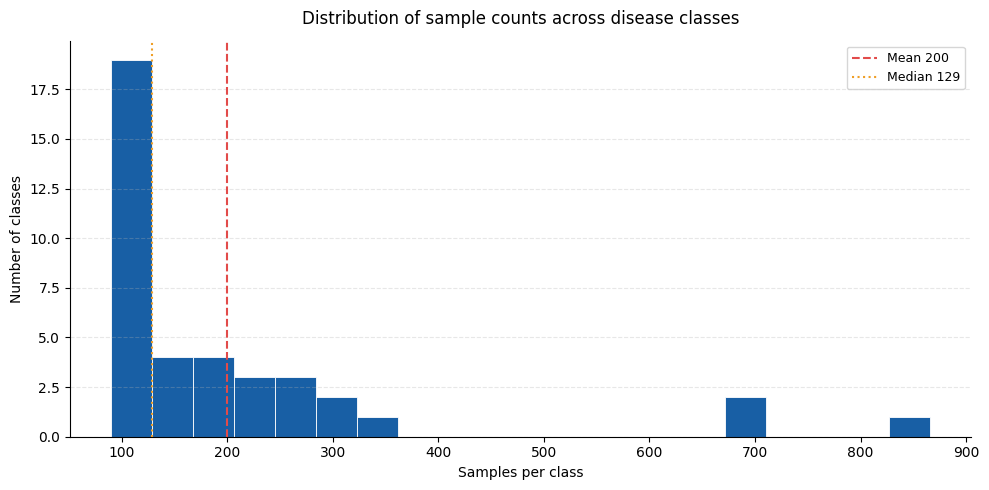

In [80]:
counts = dataset_parts["metadata_train"]["disease_label"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(counts.values, bins=20, color="#185FA5", edgecolor="white", linewidth=0.6)

ax.axvline(counts.mean(),   color="#E24B4A", linestyle="--", linewidth=1.5, label=f"Mean {counts.mean():.0f}")
ax.axvline(counts.median(), color="#EF9F27", linestyle=":",  linewidth=1.5, label=f"Median {counts.median():.0f}")
ax.legend(fontsize=9)

ax.set_xlabel("Samples per class", fontsize=10)
ax.set_ylabel("Number of classes", fontsize=10)
ax.set_title("Distribution of sample counts across disease classes", fontsize=12, pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()